In [3]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from typing import TypedDict,List
from langgraph.graph import StateGraph,START,END

load_dotenv()
API_KEY = os.getenv("GROQ_API_KEY")
if(API_KEY):
    print("ALL OK !! ")
llm = ChatGroq(
     model="llama-3.1-8b-instant", 
     temperature=0
)

ALL OK !! 


In [4]:
from typing import TypedDict

class State(TypedDict):
    question: str
    plan: str
    research: str
    answer: str

In [5]:
def planner(state: State):

    prompt = f"""
    Create a research plan for this question.

    Question:
    {state['question']}
    """

    response = llm.invoke(prompt)

    return {"plan": response.content}

In [7]:
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()

In [8]:
def research(state: State):

    results = search.invoke(state["question"])

    return {"research": results}

In [9]:
def writer(state: State):

    prompt = f"""
    Use the research below to answer the question.

    Research:
    {state['research']}

    Question:
    {state['question']}
    """

    response = llm.invoke(prompt)

    return {"answer": response.content}

In [11]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)

builder.add_node("planner", planner)
builder.add_node("research", research)
builder.add_node("writer", writer)

builder.add_edge(START, "planner")
builder.add_edge("planner", "research")
builder.add_edge("research", "writer")
builder.add_edge("writer", END)

graph = builder.compile()

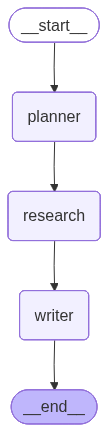

In [12]:
from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
result = graph.invoke({
    "question": "Explain the benefits of renewable energy"
})

print(result["answer"])

Based on the research provided, the benefits of renewable energy include:

1. **Even distribution around the world**: Renewable energy is more evenly distributed around the world compared to fossil fuels, which are concentrated in a limited number of countries.

2. **Health benefits**: Renewable energy reduces air pollution caused by the burning of fossil fuels, which is beneficial for our health.

3. **Climate benefits**: Renewable energy emits little to no greenhouse gases, which helps mitigate climate change.

4. **Cost-effectiveness**: Renewable energy sources, such as wind and solar, are in most cases cheaper than coal, oil, or gas.

5. **Economic benefits**: Renewable energy can save money for individuals, businesses, and industries, making it a cost-effective option for energy needs.

6. **Increased availability**: Renewable energy sources are readily available and can be used to meet residential, industrial, or commercial energy needs.

7. **Necessity in manufacturing**: The us